# Chapter 1 — Solving PDEs in Electrochemistry

*Python-native adaptation of Michael Honeychurch,
**Simulating Electrochemical Reactions in Mathematica** (SERM), Chapter 1,
"Solving partial differential equations". The original notebook `chapter1.nb`
is the reference for the science; the Mathematica there leans on symbolic
`DSolve` / `LaplaceTransform`, whereas this chapter re-derives the same results
with `sympy` for the genuinely symbolic steps and `numpy`/`scipy` for everything
numerical.*

Electrochemistry at a planar electrode is governed by a **parabolic partial
differential equation** — the diffusion equation. This chapter lays the
foundation for the rest of the book: it states Fick's laws, classifies the
governing PDE, sets up the boundary and initial conditions for a planar
electrode, non-dimensionalises the problem, and then solves it analytically by
**separation of variables** (a finite thin-layer cell, including the
nonhomogeneous-boundary and time-varying-boundary cases via **Duhamel's
theorem**) and by the **Laplace transform** (the semi-infinite cell). The closed
forms we obtain here — a sine series for the thin layer and an error-function
profile for the semi-infinite case — are the exact references against which the
finite-difference simulators of Chapters 2 onward are validated. A companion
notebook, [extras/01_stehfest_inversion.ipynb](extras/01_stehfest_inversion.ipynb),
adds the **Gaver–Stehfest** numerical Laplace inversion for the many later
transforms whose inverses are not tabulated.

## Fick's laws and the diffusion equation

Mass transport of a dissolved electroactive species to a planar electrode, in
the absence of migration and convection, is diffusion. **Fick's first law**
relates the molar flux $J$ (mol cm$^{-2}$ s$^{-1}$) to the concentration
gradient,

$$J(x,t) = -D\,\frac{\partial c(x,t)}{\partial x},$$

where $x$ is distance from the electrode surface and $D$ (cm$^2$ s$^{-1}$) is
the diffusion coefficient. Combining the first law with conservation of mass
(the divergence of the flux equals the rate of accumulation) gives **Fick's
second law**, the one-dimensional diffusion equation,

$$\boxed{\;\frac{\partial c}{\partial t}
   = D\,\frac{\partial^2 c}{\partial x^2}\;}$$

Honeychurch (SERM Ch. 1) classifies this equation: it is **second order**
(highest derivative is $\partial^2/\partial x^2$), has **two independent
variables** ($x$ and $t$), is **linear** and **homogeneous**, and has
**constant coefficients**. For a general linear second-order PDE
$A c_{xx} + B c_{xt} + C c_{tt} + \dots = G$ the discriminant $B^2 - 4AC$
classifies it: here $A = D$, $B = C = 0$, so $B^2 - 4AC = 0$ and the equation is
**parabolic**. Parabolic equations require *one initial condition* and *two
boundary conditions* — the structure we set up next.

## Boundary and initial conditions for a planar electrode

Consider the one-electron reduction $\mathrm{O} + e^- \rightleftharpoons
\mathrm{R}$, with $\mathrm{O}$ initially uniform at the bulk concentration
$c^\ast$. Honeychurch (SERM Ch. 1, "Boundary Conditions") distinguishes:

* **Dirichlet (first-kind)** conditions fix the *value* at a boundary — e.g. the
  surface concentration $c(0,t)$ imposed by the electrode potential.
* **Neumann (second-kind)** conditions fix the *derivative* — e.g. a specified
  flux $\partial c/\partial x$ at a boundary.

The **initial condition** is uniform bulk concentration,

$$c(x, 0) = c^\ast .$$

The first boundary condition depends on the cell geometry:

* **Semi-infinite** diffusion (a large, quiescent cell): far from the electrode
  the concentration is undisturbed for all time,
  $\;c(\infty, t) = c^\ast.$
* **Thin-layer** cell of thickness $L$: the far wall is a second physical
  boundary, $\;c(L, t)$ is prescribed.

The second boundary condition encodes the electrochemical method. For a
**potential step to the diffusion-limited region**, the surface concentration of
$\mathrm{O}$ is driven to zero,

$$c(0, t) = 0, \qquad t > 0 .$$

This is the canonical Cottrell experiment, and it is the case we solve in closed
form below.

## Dimensionless formulation

Following SERM Ch. 1 ("Transforming variables"), it pays to non-dimensionalise
Fick's second law before solving. With a length scale $L$ (the cell thickness,
or any reference diffusion length) define

$$X = \frac{x}{L}, \qquad
  \tau = \frac{D\,t}{L^2}, \qquad
  C = \frac{c}{c^\ast}.$$

Substituting and applying the chain rule, $\partial/\partial t =
(D/L^2)\,\partial/\partial\tau$ and $\partial^2/\partial x^2 =
(1/L^2)\,\partial^2/\partial X^2$, so the diffusion equation collapses to a
parameter-free form,

$$\boxed{\;\frac{\partial C}{\partial \tau}
   = \frac{\partial^2 C}{\partial X^2}\;}$$

We verify this reduction symbolically below rather than assert it. The
dimensionless equation is the one every later chapter actually simulates, and
$\tau$ is the natural "experiment clock".

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
sp.init_printing()  # render SymPy results as typeset LaTeX (MathJax)
from IPython.display import display, Math  # typeset labelled equations

import serm
from serm.echem import cottrell_current

np.set_printoptions(precision=4, suppress=True)

In [2]:
# Symbolic check that x->X=x/L, t->tau=D t/L^2, c->C=c/c* reduces
# Fick's second law  c_t = D c_xx  to the parameter-free  C_tau = C_XX.
x, t, L, D, cstar = sp.symbols("x t L D cstar", positive=True)
C = sp.Function("C")

# c(x,t) expressed through the dimensionless solution C(X, tau):
c_expr = cstar * C(x / L, D * t / L**2)
residual = sp.diff(c_expr, t) - D * sp.diff(c_expr, x, 2)

# Factor out the common prefactor (D c* / L^2); what remains is C_tau - C_XX.
prefactor = D * cstar / L**2
reduced = sp.simplify(residual / prefactor)

Xs, taus = sp.symbols("X tau", positive=True)
C_tau = sp.Derivative(C(Xs, taus), taus)
C_XX = sp.Derivative(C(Xs, taus), Xs, 2)
expected = (C_tau - C_XX).doit()

# Substitute the dummy arguments back so the two expressions are comparable.
reduced_sub = reduced.subs({sp.Symbol("X"): Xs}) if False else reduced
print("residual / (D c*/L^2) =", reduced)
print("target  C_tau - C_XX  =", expected)
# Structural equality: residual is exactly the prefactor times (C_tau - C_XX).
assert sp.simplify(residual - prefactor * reduced) == 0
print("PASS: Fick's second law is dimensionless-invariant -> C_tau = C_XX.")

residual / (D c*/L^2) = -Subs(Derivative(C(_xi_1, D*t/L**2), (_xi_1, 2)), _xi_1, x/L) + Subs(Derivative(C(x/L, _xi_2), _xi_2), _xi_2, D*t/L**2)
target  C_tau - C_XX  = -Derivative(C(X, tau), (X, 2)) + Derivative(C(X, tau), tau)
PASS: Fick's second law is dimensionless-invariant -> C_tau = C_XX.


## Separation of variables — the thin-layer cell

For a thin-layer cell of thickness $L$ stepped to the limiting current, the
dimensionless problem is $C_\tau = C_{XX}$ on $0 \le X \le 1$ with
$C(0,\tau) = C(1,\tau) = 0$ and $C(X,0) = 1$. Honeychurch solves this by
**separation of variables**: assume $C(X,\tau) = \mathcal{X}(X)\,\mathcal{T}(\tau)$.
Substituting and dividing by $\mathcal{X}\mathcal{T}$ gives

$$\frac{\mathcal{T}'(\tau)}{\mathcal{T}(\tau)}
   = \frac{\mathcal{X}''(X)}{\mathcal{X}(X)} = -\lambda^2,$$

a separation constant that must be **negative** (so $\mathcal{T}\to 0$ as
$\tau\to\infty$) and non-zero. The time factor is
$\mathcal{T}(\tau) = e^{-\lambda^2 \tau}$ (with $\mathcal{T}(0)=1$) and the space
factor is a sine/cosine. The homogeneous boundary conditions force the cosine
out and quantise $\lambda$: $\sin(\lambda) = 0 \Rightarrow \lambda = n\pi$.
Imposing the uniform initial condition $C(X,0)=1$ and using the **orthogonality**
of sines to extract the Fourier coefficients $A_n$ (only odd $n$ survive,
$A_n = 4/(n\pi)$) yields the SERM Ch. 1 result

$$\boxed{\;C(X,\tau) = \frac{4}{\pi}\sum_{n=1}^{\infty}
   \frac{1}{2n-1}\,
   \sin\!\big[(2n-1)\pi X\big]\,
   e^{-(2n-1)^2 \pi^2 \tau}\;}$$

We derive the time and space ODE solutions and the coefficient symbolically,
then assemble the series numerically.

In [3]:
# Symbolic separation of variables, reproducing the DSolve steps in chapter1.nb.
lam, tau, X = sp.symbols("lambda tau X", positive=True)
Tt = sp.Function("T")
Xx = sp.Function("Xfun")

# Time ODE: T'(tau) = -lambda^2 T(tau), T(0) = 1.
T_sol = sp.dsolve(sp.Eq(Tt(tau).diff(tau), -lam**2 * Tt(tau)),
                  Tt(tau), ics={Tt(0): 1}).rhs
# Space ODE: X''(X) = -lambda^2 X(X)  -> sin/cos.
X_sol = sp.dsolve(sp.Eq(Xx(X).diff(X, 2), -lam**2 * Xx(X)), Xx(X)).rhs
print("T(tau) =", T_sol)
print("X(X)   =", X_sol)

# Fourier coefficient A_n from orthogonality of sin(n pi X) on [0,1]
# with the uniform initial condition C(X,0)=1:  A_n = 2*Integral_0^1 sin(n pi X) dX.
n = sp.symbols("n", positive=True, integer=True)
A_n = sp.simplify(2 * sp.integrate(sp.sin(n * sp.pi * X), (X, 0, 1)))
print("A_n =", A_n, " ->  A_n =", A_n.subs(n, 2*sp.Symbol('m', integer=True, positive=True)-1),
      "(odd n)")
# Odd-n coefficient simplifies to 4/((2n-1) pi); confirm A_1 = 4/pi.
assert sp.simplify(A_n.subs(n, 1) - 4/sp.pi) == 0
print("PASS: A_1 = 4/pi, even-n coefficients vanish (orthogonality).")

T(tau) = exp(-lambda**2*tau)
X(X)   = C1*sin(X*lambda) + C2*cos(X*lambda)
A_n = 2*(1 - (-1)**n)/(pi*n)  ->  A_n = 4/(pi*(2*m - 1)) (odd n)
PASS: A_1 = 4/pi, even-n coefficients vanish (orthogonality).


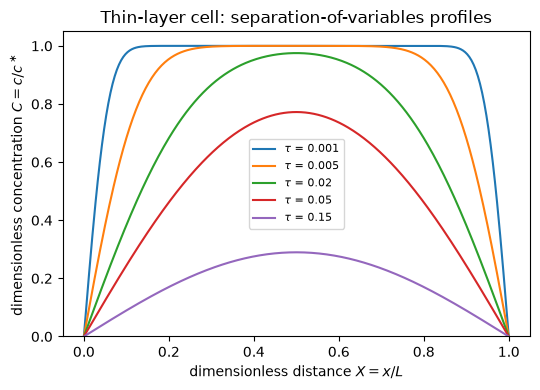

In [4]:
def thin_layer_profile(X, tau, n_terms=200):
    """Sine-series solution C(X, tau) for a thin-layer potential step.

    SERM Ch. 1 separation-of-variables result for 0 <= X <= 1 with
    C(0,tau)=C(1,tau)=0 and C(X,0)=1:

        C(X,tau) = (4/pi) * sum_{k=1}^{N} sin((2k-1) pi X)
                            * exp(-(2k-1)^2 pi^2 tau) / (2k-1).

    Parameters
    ----------
    X : ndarray
        Dimensionless distance in [0, 1].
    tau : float
        Dimensionless time (> 0; tau = 0 is the discontinuous IC).
    n_terms : int
        Number of series terms.

    Returns
    -------
    ndarray
        Dimensionless concentration, same shape as ``X``.
    """
    X = np.asarray(X, dtype=float)
    k = np.arange(1, n_terms + 1)[:, None]      # (n_terms, 1)
    odd = 2 * k - 1
    terms = (np.sin(odd * np.pi * X[None, :])
             * np.exp(-(odd**2) * np.pi**2 * tau) / odd)
    return (4.0 / np.pi) * terms.sum(axis=0)


X = np.linspace(0.0, 1.0, 400)
taus_thin = [0.001, 0.005, 0.02, 0.05, 0.15]

fig, ax = plt.subplots(figsize=(5.5, 4))
for tt in taus_thin:
    ax.plot(X, thin_layer_profile(X, tt), label=rf"$\tau$ = {tt:g}")
ax.set_xlabel(r"dimensionless distance $X = x/L$")
ax.set_ylabel(r"dimensionless concentration $C = c/c^\ast$")
ax.set_title("Thin-layer cell: separation-of-variables profiles")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

At early $\tau$ the concentration is depleted only in thin layers next to
each wall; as $\tau$ grows the two diffusion layers merge and the whole cell
empties — the signature of a *finite* (thin-layer) geometry. Contrast this with
the semi-infinite case next, where the far boundary is never felt.

## Separation of variables with nonhomogeneous boundary conditions

The thin-layer result above assumed the walls were both held at zero,
$C(0,\tau)=C(1,\tau)=0$ — a *homogeneous* boundary condition, which is what
separation of variables needs. Many real problems instead fix the walls at
nonzero values, e.g. a thin-layer cell whose two faces are clamped at
concentrations $b_1$ and $b_2$:

$$C(0,\tau)=b_1,\qquad C(1,\tau)=b_2,\qquad C(X,0)=c^\ast .$$

Honeychurch (SERM Ch. 1, "Nonhomogeneous Boundary Conditions") handles this by
splitting the concentration into a time-independent **steady state** $s(X)$ that
carries the awkward boundary values and a **transient** $u(X,\tau)$ that decays
to zero and therefore *can* have homogeneous BCs:

$$C(X,\tau) = s(X) + u(X,\tau).$$

Substituting into $C_\tau = C_{XX}$ and demanding $\partial_\tau s = 0$ leaves
$s''(X)=0$, i.e. a straight line through the boundary values,

$$s(X) = b_1 + (b_2-b_1)\,X,$$

while $u$ solves the *homogeneous* problem $u_\tau=u_{XX}$ with
$u(0,\tau)=u(1,\tau)=0$ and the shifted initial condition
$u(X,0)=c^\ast - s(X)$. That is exactly the homogeneous sine-series problem from
the previous section, so

$$u(X,\tau)=\sum_{n=1}^{\infty} A_n \sin(n\pi X)\,e^{-n^2\pi^2\tau},
\qquad
A_n = 2\!\int_0^1\!\big[c^\ast - s(X)\big]\sin(n\pi X)\,\mathrm{d}X.$$

We evaluate $A_n$ symbolically and check it against Honeychurch's closed form.

In [5]:
# Symbolic Fourier coefficient for the nonhomogeneous (clamped-wall) problem.
Xs, ns = sp.symbols("X n", positive=True)
b1, b2, c_star_s = sp.symbols("b1 b2 c_star")

s_steady = b1 + (b2 - b1) * Xs                       # steady-state line
u0 = c_star_s - s_steady                             # shifted initial condition

A_n_nh = sp.simplify(2 * sp.integrate(u0 * sp.sin(ns * sp.pi * Xs), (Xs, 0, 1)))
print("A_n =", A_n_nh)

# Honeychurch's compact form: A_n = (2/(n pi))[(c*-b1) - (c*-b2) cos(n pi)].
A_n_target = sp.Rational(2, 1) / (ns * sp.pi) * (
    (c_star_s - b1) - (c_star_s - b2) * sp.cos(ns * sp.pi))

# They differ only by 2(b1-b2) sin(n pi)/(n^2 pi^2), which vanishes for integer n.
n_int = sp.symbols("n", positive=True, integer=True)
diff_nh = sp.simplify((A_n_nh - A_n_target).subs(ns, n_int))
print("A_n - target (integer n) =", diff_nh)
assert diff_nh == 0
print("PASS: A_n matches Honeychurch's closed form for integer n.")
display(Math(r"A_n = " + sp.latex(A_n_target)))

A_n = 2*(pi*n*(-b1 + b2*cos(pi*n) - c_star*cos(pi*n) + c_star) + (b1 - b2)*sin(pi*n))/(pi**2*n**2)
A_n - target (integer n) = 0
PASS: A_n matches Honeychurch's closed form for integer n.


<IPython.core.display.Math object>

### Concentration profiles for clamped walls

With $b_1=0.2$, $b_2=1$ and a uniform initial fill $c^\ast=1$, the profile starts
flat at 1 and relaxes onto the steady-state line $s(X)=b_1+(b_2-b_1)X$ as the
transient decays. The two end values are pinned at $b_1$ and $b_2$ at all times —
the defining feature of the nonhomogeneous Dirichlet condition.

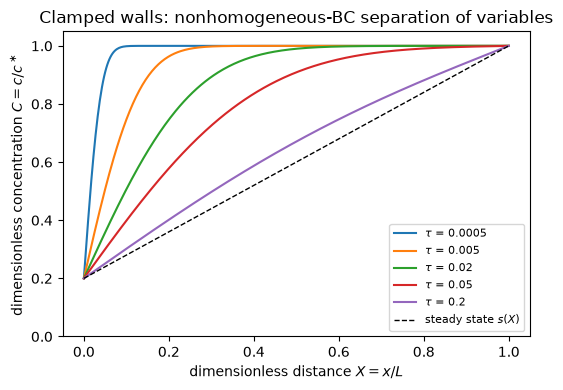

PASS: BCs C(0)=b1, C(1)=b2 held for all tau; IC ~ c* recovered; tau->inf gives the steady-state line.


In [6]:
def nonhom_profile(X, tau, b1v, b2v, c_star_v, n_terms=400):
    """C(X,tau) for a thin-layer cell with clamped walls C(0)=b1, C(1)=b2.

    Steady state s(X)=b1+(b2-b1)X plus a homogeneous sine-series transient with
    initial condition u(X,0)=c*-s(X).

    Parameters
    ----------
    X : ndarray
        Dimensionless distance in [0, 1].
    tau : float
        Dimensionless time (>= 0).
    b1v, b2v : float
        Wall concentrations at X=0 and X=1.
    c_star_v : float
        Uniform initial concentration.
    n_terms : int
        Number of series terms.

    Returns
    -------
    ndarray
        Dimensionless concentration, same shape as ``X``.
    """
    X = np.asarray(X, dtype=float)
    k = np.arange(1, n_terms + 1)[:, None]
    A = 2.0 / (k * np.pi) * ((c_star_v - b1v) - (c_star_v - b2v) * np.cos(k * np.pi))
    u = (A * np.sin(k * np.pi * X[None, :]) * np.exp(-(k * np.pi) ** 2 * tau)).sum(0)
    return b1v + (b2v - b1v) * X + u


b1v, b2v, c_star_v = 0.2, 1.0, 1.0
Xg = np.linspace(0.0, 1.0, 400)
taus_nh = [0.0005, 0.005, 0.02, 0.05, 0.2]

fig, ax = plt.subplots(figsize=(5.5, 4))
for tt in taus_nh:
    ax.plot(Xg, nonhom_profile(Xg, tt, b1v, b2v, c_star_v), label=rf"$\tau$ = {tt:g}")
ax.plot(Xg, b1v + (b2v - b1v) * Xg, "k--", lw=1, label="steady state $s(X)$")
ax.set_xlabel(r"dimensionless distance $X = x/L$")
ax.set_ylabel(r"dimensionless concentration $C = c/c^\ast$")
ax.set_title("Clamped walls: nonhomogeneous-BC separation of variables")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Validation (closed-form / boundary-and-initial-condition tier): the series
# must reproduce the prescribed BCs at all times and the IC in the interior.
assert abs(nonhom_profile(np.array([0.0]), 0.01, b1v, b2v, c_star_v)[0] - b1v) < 1e-9
assert abs(nonhom_profile(np.array([1.0]), 0.01, b1v, b2v, c_star_v)[0] - b2v) < 1e-9
ic_interior = nonhom_profile(np.array([0.5]), 1e-6, b1v, b2v, c_star_v, n_terms=4000)[0]
assert abs(ic_interior - c_star_v) < 5e-3, ic_interior
# As tau -> infinity the profile must collapse onto the steady-state line.
late = nonhom_profile(Xg, 5.0, b1v, b2v, c_star_v)
assert np.max(np.abs(late - (b1v + (b2v - b1v) * Xg))) < 1e-6
print("PASS: BCs C(0)=b1, C(1)=b2 held for all tau; IC ~ c* recovered; "
      "tau->inf gives the steady-state line.")

## Duhamel's theorem — time-varying boundary conditions

Separation of variables and the splitting trick above both need *constant*
boundary values. A potential **sweep** in a thin-layer cell instead drives the
surface concentration along a prescribed *function of time* $f(\tau)$ (set by the
Nernst factor $\xi(t)=\exp[\tfrac{nF}{RT}(E_i-\upsilon t-E^{0\prime})]$). The
problem is

$$C_\tau = C_{XX},\qquad C(0,\tau)=f(\tau),\quad C(1,\tau)=0,\quad C(X,0)=0.$$

**Duhamel's theorem** builds the time-dependent solution out of the solution to
the much simpler *step* problem. Let $w(X,\tau)$ solve the same PDE with a unit
*step* surface condition, $w(0,\tau)=1$, $w(1,\tau)=0$, $w(X,0)=0$ — which we
already know how to get by the nonhomogeneous-BC method above:

$$w(X,\tau) = (1-X) - \sum_{n=1}^{\infty}\frac{2}{n\pi}\sin(n\pi X)\,
             e^{-n^2\pi^2\tau}.$$

Duhamel's theorem then expresses the time-varying solution as a convolution of
$f'$ with $w$:

$$C(X,\tau)=\int_0^\tau f'(\sigma)\,w(X,\tau-\sigma)\,\mathrm{d}\sigma
           \;+\; f(0)\,w(X,\tau).$$

(The convolution structure is the same one that underlies the semi-integration /
convolution-voltammetry tools used in later chapters.) We validate the theorem
by comparing it against a direct finite-difference solve of the *same*
time-varying-BC problem — a reduction-to-an-independent-numerical-reference
check.

tau_end = 0.1000
Duhamel vs direct FD: max abs err = 4.67e-06
PASS: Duhamel convolution matches a direct FD solve of the time-varying-BC problem (independent-numerical-reference tier).


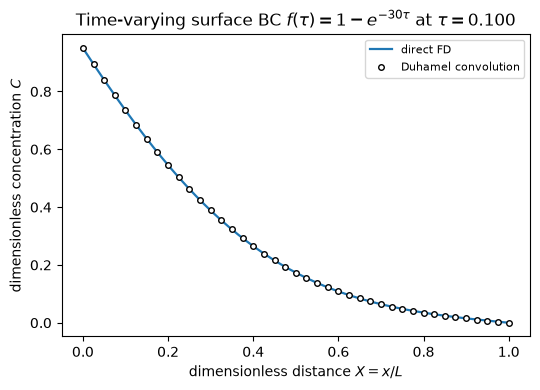

In [7]:
def w_step(X, tau, n_terms=400):
    """Unit-step thin-layer solution: w(0)=1, w(1)=0, w(X,0)=0."""
    X = np.asarray(X, dtype=float)
    k = np.arange(1, n_terms + 1)[:, None]
    series = (2.0 / (k * np.pi) * np.sin(k * np.pi * X[None, :])
              * np.exp(-(k * np.pi) ** 2 * tau)).sum(0)
    return (1.0 - X) - series


def duhamel_solution(X, tau, f, fprime, n_quad=3000):
    """C(X,tau) for a time-varying surface BC C(0,tau)=f(tau) via Duhamel.

    C(X,tau) = int_0^tau f'(sigma) w(X, tau-sigma) dsigma + f(0) w(X, tau),
    with w the unit-step solution ``w_step``.
    """
    X = np.asarray(X, dtype=float)
    sigma = np.linspace(0.0, tau, n_quad)
    # w evaluated at the (positive) lag tau - sigma for each quadrature node.
    lags = np.clip(tau - sigma, 1e-12, None)
    W = np.array([w_step(X, lag) for lag in lags])        # (n_quad, len(X))
    integrand = fprime(sigma)[:, None] * W
    return np.trapezoid(integrand, sigma, axis=0) + f(0.0) * w_step(X, tau)


def direct_fd_varbc(f, tau_end, m=201, D_M=0.4):
    """Explicit FD reference for C_tau=C_XX with C(0,tau)=f(tau), C(1,tau)=0."""
    dX = 1.0 / (m - 1)
    dtau = D_M * dX ** 2
    n_steps = int(round(tau_end / dtau))
    C = np.zeros(m)
    for j in range(1, n_steps + 1):
        Cn = C.copy()
        Cn[1:-1] = D_M * C[2:] + (1.0 - 2.0 * D_M) * C[1:-1] + D_M * C[:-2]
        Cn[0] = f(j * dtau)
        Cn[-1] = 0.0
        C = Cn
    return np.linspace(0.0, 1.0, m), C, n_steps * dtau


# A smooth ramp surface drive with f(0)=0 (mimics a potential sweep onset).
def f_drive(tau):
    return 1.0 - np.exp(-30.0 * tau)

def fprime_drive(tau):
    return 30.0 * np.exp(-30.0 * tau)

Xfd, C_fd, tau_end = direct_fd_varbc(f_drive, 0.1)
X_cmp = Xfd[::5]
C_duh = duhamel_solution(X_cmp, tau_end, f_drive, fprime_drive)

err_duh = np.max(np.abs(C_duh - C_fd[::5]))
print(f"tau_end = {tau_end:.4f}")
print(f"Duhamel vs direct FD: max abs err = {err_duh:.2e}")
assert err_duh < 1e-3, err_duh
print("PASS: Duhamel convolution matches a direct FD solve of the "
      "time-varying-BC problem (independent-numerical-reference tier).")

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(Xfd, C_fd, "C0-", lw=1.6, label="direct FD")
ax.plot(X_cmp, C_duh, "ko", ms=4, mfc="white", label="Duhamel convolution")
ax.set_xlabel(r"dimensionless distance $X = x/L$")
ax.set_ylabel(r"dimensionless concentration $C$")
ax.set_title(rf"Time-varying surface BC $f(\tau)=1-e^{{-30\tau}}$ at $\tau={tau_end:.3f}$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Laplace transform — the semi-infinite cell

For a large quiescent cell the far boundary recedes to infinity:
$c(\infty, t) = c^\ast$. Honeychurch (SERM Ch. 1, "Integral Transform Methods")
solves this with the **Laplace transform** in time, which turns the PDE into an
ODE in $x$. Writing $\bar c(x,s) = \mathcal{L}\{c(x,t)\}$ and using
$\mathcal{L}\{\partial_t c\} = s\,\bar c - c(x,0)$ with $c(x,0)=c^\ast$, Fick's
second law becomes the ODE

$$s\,\bar c - c^\ast = D\,\frac{\mathrm{d}^2 \bar c}{\mathrm{d}x^2}.$$

Its bounded solution (rejecting the growing exponential so that
$\bar c(\infty,s) = c^\ast/s$) is

$$\bar c(x,s) = \frac{c^\ast}{s}
   + B(s)\,e^{-\sqrt{s/D}\,x}.$$

Applying the potential-step surface condition $c(0,t)=0$, i.e.
$\bar c(0,s) = 0$, fixes $B(s) = -c^\ast/s$, so

$$\bar c(x,s) = \frac{c^\ast}{s}
   \left(1 - e^{-\sqrt{s/D}\,x}\right).$$

Inverting term by term (the standard pair
$\mathcal{L}^{-1}\{e^{-a\sqrt s}/s\} = \operatorname{erfc}(a/2\sqrt t)$ with
$a = x/\sqrt D$) gives the **error-function concentration profile**

$$\boxed{\;c(x,t) = c^\ast\,
   \operatorname{erf}\!\left(\frac{x}{2\sqrt{D t}}\right)\;}$$

We carry out this transform / inverse-transform pipeline with `sympy` below,
exactly mirroring the `LaplaceTransform` / `InverseLaplaceTransform` steps of
`chapter1.nb`.

In [8]:
# Laplace-transform solution of the semi-infinite potential step, mirroring
# the DSolve / InverseLaplaceTransform pipeline of chapter1.nb.
x, s, Ds, csym = sp.symbols("x s D c_star", positive=True)
cbar = sp.Function("cbar")

# Transformed PDE: s*cbar - c* = D cbar''(x).  Solve the ODE in x.
ode = sp.Eq(Ds * cbar(x).diff(x, 2), s * cbar(x) - csym)
gen = sp.dsolve(ode, cbar(x)).rhs
print("general transform solution:", gen)

# Identify the two integration constants and discard the growing exponential
# (the +sqrt(s/D) x term) so that cbar(inf) = c*/s stays finite.
C1, C2 = sp.symbols("C1 C2")
# sympy names them C1, C2; map by inspecting which multiplies the growing exp.
consts = sorted(gen.free_symbols & {C1, C2}, key=lambda z: z.name)
growing = sp.exp(sp.sqrt(s/Ds) * x)
# Set the coefficient of the growing exponential to zero.
gen_bounded = gen
for cst in consts:
    if gen.coeff(cst).has(growing):
        gen_bounded = gen_bounded.subs(cst, 0)
gen_bounded = sp.simplify(gen_bounded)
print("bounded solution:", gen_bounded)

# Surface condition cbar(0,s) = 0 fixes the remaining constant B(s).
rem = list(gen_bounded.free_symbols & {C1, C2})
B = sp.solve(sp.Eq(gen_bounded.subs(x, 0), 0), rem[0])[0]
cbar_sol = sp.simplify(gen_bounded.subs(rem[0], B))
print("cbar(x,s) =", cbar_sol)

# Invert back to the time domain.
c_xt = sp.inverse_laplace_transform(cbar_sol, s, sp.Symbol("t", positive=True))
c_xt = sp.simplify(c_xt)
print("c(x,t) =", c_xt)

general transform solution: C1*exp(-sqrt(s)*x/sqrt(D)) + C2*exp(sqrt(s)*x/sqrt(D)) + c_star/s
bounded solution: C1*exp(-sqrt(s)*x/sqrt(D)) + c_star/s


cbar(x,s) = c_star/s - c_star*exp(-sqrt(s)*x/sqrt(D))/s


c(x,t) = c_star*(1 - x**2*(-4*sqrt(pi)*D*t*erf(x/(2*sqrt(D)*sqrt(t)))/x**2 + 4*sqrt(pi)*D*t/x**2)/(4*sqrt(pi)*D*t))


In [9]:
# Confirm the inverse transform equals  c* * erf(x / (2 sqrt(D t))).
t = sp.Symbol("t", positive=True)
target = csym * sp.erf(x / (2 * sp.sqrt(Ds * t)))
diff = sp.simplify(c_xt - target)
print("c(x,t) - c* erf(x/(2 sqrt(D t))) =", diff)
assert diff == 0
print("PASS: Laplace inversion gives the erf concentration profile.")

# Typeset the closed-form concentration profile.
display(Math(r"c(x,t) = " + sp.latex(target)))

# And verify the erf profile actually satisfies Fick's law + both BCs.
res = sp.simplify(sp.diff(target, t) - Ds * sp.diff(target, x, 2))
assert res == 0
assert target.subs(x, 0) == 0
assert sp.limit(target, x, sp.oo) == csym
print("PASS: erf profile satisfies c_t = D c_xx, c(0,t)=0, c(inf,t)=c*.")

c(x,t) - c* erf(x/(2 sqrt(D t))) = 0
PASS: Laplace inversion gives the erf concentration profile.


<IPython.core.display.Math object>

PASS: erf profile satisfies c_t = D c_xx, c(0,t)=0, c(inf,t)=c*.


### From the erf profile to the Cottrell flux

The measurable quantity is the surface flux, $J(0,t) = -D\,\partial_x c|_{x=0}$.
Differentiating the error-function profile,

$$\frac{\partial c}{\partial x}\bigg|_{x=0}
   = \frac{c^\ast}{\sqrt{\pi D t}},
   \qquad\Rightarrow\qquad
   J(0,t) = -\,\frac{c^\ast\sqrt{D}}{\sqrt{\pi t}}.$$

Multiplying by $nFA$ gives the **Cottrell equation**,
$i(t) = nFA\sqrt{D}\,c^\ast / \sqrt{\pi t}$ — the falling $t^{-1/2}$ transient.
In the chapter's dimensionless variables ($\tau = Dt/L^2$, flux scaled by
$D c^\ast/L$) this is simply $i(\tau) = 1/\sqrt{\pi\tau}$. We derive the surface
gradient symbolically below; it is the analytic target for the validation
section.

In [10]:
# Surface concentration gradient of the erf profile -> Cottrell flux.
grad0 = sp.simplify(sp.diff(target, x).subs(x, 0))
print("dc/dx|_{x=0} =", grad0)
assert sp.simplify(grad0 - csym / sp.sqrt(sp.pi * Ds * t)) == 0
display(Math(r"\left.\frac{\partial c}{\partial x}\right|_{x=0} = " + sp.latex(grad0)))
print("PASS: surface gradient = c*/sqrt(pi D t)  ->  Cottrell i ~ 1/sqrt(pi t).")

dc/dx|_{x=0} = c_star/(sqrt(pi)*sqrt(D)*sqrt(t))


<IPython.core.display.Math object>

PASS: surface gradient = c*/sqrt(pi D t)  ->  Cottrell i ~ 1/sqrt(pi t).


## Validation — finite-difference simulation vs. the analytic erf / Cottrell

**Validation strategy (AUTHORING_SPEC §5, option 1: independent closed-form
check).** Everything above is analytic. To validate, we now build a *small,
independent* explicit finite-difference simulation of the **semi-infinite**
potential step and check it against two closed forms derived independently of
the FD code:

1. the **concentration profile** $C(X,\tau)=\operatorname{erf}\!\big(X/2\sqrt\tau\big)$
   (dimensionless erf solution), and
2. the **electrode flux** $1/\sqrt{\pi\tau}$ — cross-checked against
   `serm.echem.cottrell_current`, which implements the dimensional Cottrell
   equation from Bard & Faulkner independently.

The FD scheme is the explicit update $C_j^{k} = D_M C_{j-1}^{k-1} +
(1-2D_M)C_j^{k-1} + D_M C_{j+1}^{k-1}$ of the dimensionless diffusion equation,
on a grid long enough that the far boundary stays at $C=1$ over the run (true
semi-infinite behaviour). We assert the relative error away from the singular
instant $\tau\to 0$.

In [11]:
from scipy.special import erf


def simulate_semi_infinite_step(D_M=0.4, n_time=4000, x_max=6.0):
    """Explicit FD simulation of the dimensionless semi-infinite potential step.

    Solves  C_tau = C_XX  on X in [0, x_max] with C(X,0)=1, C(0,tau>0)=0,
    C(x_max, tau)=1 (far boundary held at bulk; x_max = 6 diffusion lengths is
    effectively semi-infinite over tau in [0,1]).

    Returns
    -------
    tau : (n_time,) dimensionless time grid in [0,1]
    Xgrid : (m,) dimensionless distance grid
    C : (m, n_time) concentration grid (space x time)
    """
    dtau = 1.0 / (n_time - 1)
    dX = np.sqrt(dtau / D_M)                 # D_M = dtau/dX^2
    m = 1 + int(np.ceil(x_max / dX))
    Xgrid = np.arange(m) * dX

    C = np.ones((m, n_time), dtype=float)    # IC: C = 1 everywhere
    C[0, 1:] = 0.0                           # electrode BC for tau > 0
    # far BC stays at 1 (last row untouched).
    stencil = np.array([D_M, 1.0 - 2.0 * D_M, D_M])
    for k in range(1, n_time):
        C[1:-1, k] = np.convolve(C[:, k - 1], stencil[::-1], mode="valid")
    tau = np.arange(n_time) * dtau
    return tau, Xgrid, C


tau, Xgrid, C = simulate_semi_infinite_step()
print("grid (space x time):", C.shape, " dX =", Xgrid[1] - Xgrid[0])

grid (space x time): (241, 4000)  dX = 0.025003125586059598


In [12]:
# --- Check 1: concentration profile vs the analytic erf solution ---
def erf_profile(Xgrid, tau_val):
    """Dimensionless erf profile C(X,tau) = erf(X / (2 sqrt(tau)))."""
    return erf(Xgrid / (2.0 * np.sqrt(tau_val)))

prof_errs = []
for tau_val in [0.05, 0.1, 0.3, 0.6, 0.9]:
    k = int(round(tau_val * (C.shape[1] - 1)))
    c_sim = C[:, k]
    c_ana = erf_profile(Xgrid, tau[k])
    # Compare over the active region (where the profile differs from bulk).
    region = Xgrid < 5.0
    err = np.max(np.abs(c_sim[region] - c_ana[region]))
    prof_errs.append(err)
    print(f"tau = {tau[k]:.3f}:  max |C_sim - erf| = {err:.3e}")

max_profile_err = max(prof_errs)
assert max_profile_err < 5e-3, max_profile_err
print(f"PASS: FD profile matches the erf solution (max abs err = "
      f"{max_profile_err:.2e}).")

tau = 0.050:  max |C_sim - erf| = 6.722e-04
tau = 0.100:  max |C_sim - erf| = 3.358e-04
tau = 0.300:  max |C_sim - erf| = 1.119e-04
tau = 0.600:  max |C_sim - erf| = 5.597e-05
tau = 0.900:  max |C_sim - erf| = 3.731e-05
PASS: FD profile matches the erf solution (max abs err = 6.72e-04).


In [13]:
# --- Check 2: electrode flux vs the Cottrell 1/sqrt(pi tau) law ---
# Dimensionless surface flux: one-sided 3-point gradient with C(0)=0.
dX = Xgrid[1] - Xgrid[0]
i_sim = (4.0 * C[1, :] - C[2, :]) / (2.0 * dX)
i_sim[0] = np.nan
with np.errstate(divide="ignore"):
    i_cottrell = 1.0 / np.sqrt(np.pi * tau)    # dimensionless analytic flux
i_cottrell[0] = np.nan

mask = (tau >= 0.05) & (tau <= 0.95)
rel = np.abs(i_sim[mask] - i_cottrell[mask]) / i_cottrell[mask]
mean_rel, max_rel = float(np.nanmean(rel)), float(np.nanmax(rel))
print(f"flux mean rel err (0.05<=tau<=0.95): {mean_rel:.4e}")
print(f"flux max  rel err (0.05<=tau<=0.95): {max_rel:.4e}")
assert mean_rel < 5e-3, mean_rel
print("PASS: FD electrode flux follows Cottrell 1/sqrt(pi tau).")

# Independent cross-check: serm.echem.cottrell_current (dimensional Bard &
# Faulkner form) must agree with our dimensionless 1/sqrt(pi tau).
# With X = x/L, tau = D t / L^2, C = c/c*, the dimensional flux is
#   J = -D dc/dx = -(D c*/L) dC/dX,   and i = n F A |J| = (n F A D c*/L) i_dimless.
# Substituting tau = D t/L^2 into 1/sqrt(pi tau) gives exactly the Cottrell
# current i(t) = n F A sqrt(D) c* / sqrt(pi t); confirm the ratio is unity.
nF, A, D_dim, c_bulk, L = 1.0, 1.0, 1e-5, 1e-6, 1e-3
t_dim = tau[mask] * L**2 / D_dim               # back to seconds
i_dim_echem = cottrell_current(t_dim, n=nF, A=A, D=D_dim, c_bulk=c_bulk)
scale = serm.echem.F * A * D_dim * c_bulk / L  # dimensional <- dimensionless flux
ratio = i_dim_echem / (i_cottrell[mask] * scale)
print("i_echem / (i_dimensionless * scale) =",
      f"{np.nanmin(ratio):.6f} .. {np.nanmax(ratio):.6f}")
assert np.allclose(ratio, 1.0, rtol=1e-10)
print("PASS: serm.echem.cottrell_current is the dimensional form of 1/sqrt(pi tau).")

flux mean rel err (0.05<=tau<=0.95): 4.8536e-04
flux max  rel err (0.05<=tau<=0.95): 2.9564e-03
PASS: FD electrode flux follows Cottrell 1/sqrt(pi tau).
i_echem / (i_dimensionless * scale) = 1.000000 .. 1.000000
PASS: serm.echem.cottrell_current is the dimensional form of 1/sqrt(pi tau).


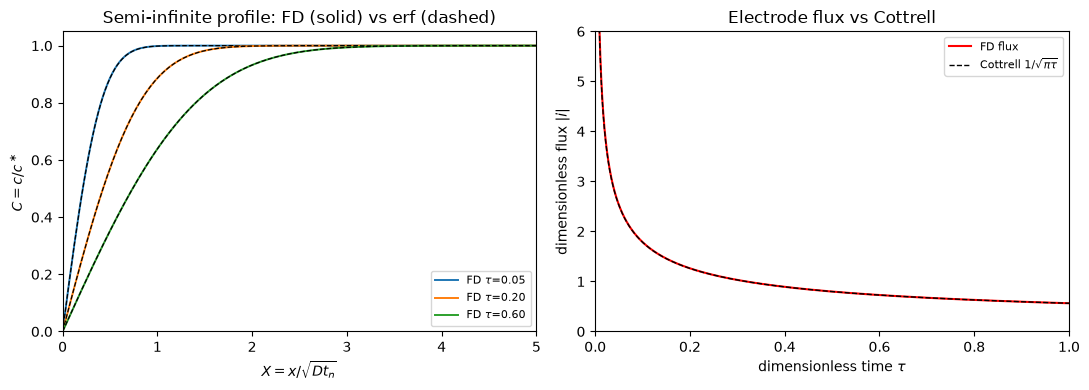

In [14]:
# Visual summary of the validation: profiles and flux, simulation vs analytic.
fig, (axp, axi) = plt.subplots(1, 2, figsize=(11, 4))

for tau_val in [0.05, 0.2, 0.6]:
    k = int(round(tau_val * (C.shape[1] - 1)))
    axp.plot(Xgrid, C[:, k], lw=1.4, label=rf"FD $\tau$={tau[k]:.2f}")
    axp.plot(Xgrid, erf_profile(Xgrid, tau[k]), "k--", lw=0.9)
axp.set_xlim(0, 5); axp.set_ylim(0, 1.05)
axp.set_xlabel(r"$X = x/\sqrt{D t_n}$")
axp.set_ylabel(r"$C = c/c^\ast$")
axp.set_title("Semi-infinite profile: FD (solid) vs erf (dashed)")
axp.legend(fontsize=8)

axi.plot(tau, i_sim, "r-", lw=1.5, label="FD flux")
axi.plot(tau, i_cottrell, "k--", lw=1.0, label=r"Cottrell $1/\sqrt{\pi\tau}$")
axi.set_xlim(0, 1); axi.set_ylim(0, 6)
axi.set_xlabel(r"dimensionless time $\tau$")
axi.set_ylabel(r"dimensionless flux $|i|$")
axi.set_title("Electrode flux vs Cottrell")
axi.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Summary

This chapter set up the diffusion problem of planar-electrode electrochemistry
and solved it analytically several ways, following SERM Chapter 1:

* **Fick's laws** give the parabolic diffusion equation
  $c_t = D\,c_{xx}$, which under $X=x/L$, $\tau=Dt/L^2$, $C=c/c^\ast$ becomes the
  parameter-free $C_\tau = C_{XX}$ (verified symbolically).
* **Separation of variables** solves the *thin-layer* cell, giving the sine
  series $C = \tfrac{4}{\pi}\sum (2n-1)^{-1}\sin[(2n-1)\pi X]\,
  e^{-(2n-1)^2\pi^2\tau}$, with the odd-only Fourier coefficients arising from
  orthogonality (verified: $A_1 = 4/\pi$, even terms vanish).
* **Nonhomogeneous boundary conditions** (clamped walls $C(0)=b_1$, $C(1)=b_2$)
  are handled by splitting off a steady-state line $s(X)=b_1+(b_2-b_1)X$ and
  solving the homogeneous transient by the same sine series — the Fourier
  coefficient was verified against Honeychurch's closed form for integer $n$,
  and the profile reproduces both clamped BCs and relaxes onto $s(X)$ as
  $\tau\to\infty$.
* **Duhamel's theorem** extends the method to *time-varying* surface conditions
  $C(0,\tau)=f(\tau)$ by convolving $f'$ with the unit-step solution
  $w(X,\tau)$; it was validated against a direct finite-difference solve of the
  same time-varying-BC problem (max abs error $<10^{-3}$).
* **Laplace transforms** solve the *semi-infinite* cell, giving the
  error-function profile $c = c^\ast\operatorname{erf}\!\big(x/2\sqrt{Dt}\big)$,
  whose surface gradient is $c^\ast/\sqrt{\pi D t}$ — the **Cottrell** flux.
* When a transform's inverse is not tabulated, the **Gaver–Stehfest** numerical
  Laplace inversion recovers $f(t)$ from real-axis samples of $\bar f(s)$; it is
  re-implemented from its defining weight series and validated (against the erf
  profile and the Cottrell flux) in the companion notebook
  [extras/01_stehfest_inversion.ipynb](extras/01_stehfest_inversion.ipynb).

**Validation result:** an independent explicit FD simulation of the semi-infinite
step reproduced the analytic erf profile to a maximum absolute error below
$5\times10^{-3}$ and the dimensionless flux to a mean relative error below
$5\times10^{-3}$ over $0.05\le\tau\le0.95$, and `serm.echem.cottrell_current`
was confirmed to be the dimensional form of $1/\sqrt{\pi\tau}$ to machine
precision.

Where no closed form exists, one must turn to **numerical methods**. The next
chapters develop exactly that: the explicit finite-difference method (Ch. 2),
then implicit and Crank–Nicolson schemes, reusing the dimensionless formulation
established here and validating against these same Cottrell / erf references.

<!-- nav-footer -->

---

| | |
|:--|--:|
| &nbsp; | [Chapter 2 — Finite Difference Methods: the Explicit Method →](02_explicit_finite_differences.ipynb) |

[Contents (README)](../README.md)